# 04 — Modelación por Regresión Lineal Múltiple

## 1. Marco Teórico
La regresión lineal múltiple permite cuantificar el efecto simultáneo de múltiples variables predictoras ambientales ($X_1, X_2, \dots, X_p$) y variables de control de esfuerzo de muestreo (Duración y Distancia) sobre la biodiversidad medida por el índice de Shannon ($Y$).

El modelo general se expresa como:
$$Y_i = \beta_0 + \beta_1 X_{1i} + \beta_2 X_{2i} + \dots + \beta_p X_{pi} + \epsilon_i$$
donde $\beta_j$ son los coeficientes a estimar y $\epsilon_i$ representa el error aleatorio, que bajo los supuestos clásicos de Gauss-Markov cumple:
1. $E[\epsilon_i] = 0$ (linealidad).
2. $Var(\epsilon_i) = \sigma^2$ (homocedasticidad).
3. $Cov(\epsilon_i, \epsilon_j) = 0$ para $i \neq j$ (independencia).
4. Ausencia de multicolinealidad perfecta.
5. $\epsilon_i \sim N(0, \sigma^2)$ (normalidad de residuales) para la inferencia clásica sobre significancia de coeficientes.

### Inferencia Robusta a la Heterocedasticidad (Errores HC3)
En presencia de heterocedasticidad (varianza no constante de residuales), los estimadores OLS de los coeficientes siguen siendo insesgados, pero los errores estándar calculados de forma clásica están sesgados, lo que puede inflar la tasa de falsos positivos ($p$-valores espurios).

Para resolver esto, aplicamos estimadores sándwich robustos del tipo **HC3** (propuestos por MacKinnon y White), que ajustan la matriz de covarianza de los coeficientes mediante la ponderación de los residuales al cuadrado por los elementos de la diagonal de la matriz de proyección (*hat matrix*, $h_{ii}$):
$$\Sigma_{HC3} = (X^T X)^{-1} X^T \text{diag}\left( \frac{e_i^2}{(1-h_{ii})^2} \right) X (X^T X)^{-1}$$
El factor de ponderación $(1-h_{ii})^2$ es óptimo para evitar subestimar los errores en muestras grandes con puntos de alto apalancamiento (*leverage*).

### Multicolinealidad (VIF)
El Factor de Inflación de Varianza (VIF) de un predictor $j$ mide cuánto se infla la varianza de su coeficiente debido a la correlación lineal con los demás predictores:
$$VIF_j = \frac{1}{1 - R_j^2}$$
donde $R_j^2$ es el coeficiente de determinación de la regresión de $X_j$ sobre todas las demás variables predictoras. Un VIF superior a 5 o 10 indica problemas severos de multicolinealidad, lo que dificulta discernir los efectos individuales de cada variable y aconseja un análisis de sensibilidad eliminando variables redundantes.

In [34]:
from pathlib import Path
import os

ROOT = Path.cwd().parent if Path.cwd().name == 'Notebooks' else Path.cwd()
os.chdir(ROOT)

import pandas as pd
import IPython.display as display
import importlib.util
spec = importlib.util.spec_from_file_location('reg', ROOT / 'Scripts/10_multiple_regression.py')
reg = importlib.util.module_from_spec(spec)
spec.loader.exec_module(reg)

df = reg.load_model_data()
model, robust_model, x, y = reg.fit_model(df)
print(f"Modelo ajustado sobre {df.shape[0]} observaciones completas.")
print(f"Predictores incluidos: {reg.PREDICTORS}")

Modelo ajustado sobre 5298 observaciones completas.
Predictores incluidos: ['z_reg_PM2.5', 'z_reg_PM10', 'z_reg_NO2', 'z_reg_CO', 'z_reg_O3', 'z_reg_Temperatura', 'z_reg_Humedad', 'z_reg_Viento', 'z_reg_Lluvia', 'z_reg_Radiacion_Solar', 'z_reg_DURATION MINUTES', 'z_reg_EFFORT DISTANCE KM']


## 2. Coeficientes Estandarizados OLS y Ajuste Robusto (HC3)
Mostramos la tabla de coeficientes estandarizados. Dado que todas las variables predictoras del modelo fueron previamente centradas y reducidas a escala $Z$, la magnitud absoluta de sus coeficientes $\beta$ refleja directamente el peso o la importancia relativa de cada predictor en la respuesta.

Comparamos la desviación estándar clásica frente a los errores estándar robustos HC3 para comprobar la estabilidad de los p-valores.

=== COEFICIENTES DEL MODELO DE REGRESIÓN (ESTANDARIZADOS Z) ===


,variable,coef,std_err,p_value,robust_hc3_std_err,robust_hc3_p_value
0,const,2.2024,0.0069,0.0000,0.0070,0.0000
1,PM2.5,0.0411,0.0125,0.0010,0.0127,0.0012
2,PM10,-0.0207,0.0126,0.1014,0.0132,0.1163
3,NO2,-0.0234,0.0100,0.0196,0.0105,0.0261
4,CO,-0.0293,0.0101,0.0039,0.0105,0.0055
5,O3,-0.0316,0.0125,0.0117,0.0138,0.0222
6,Temperatura,-0.0800,0.0152,0.0000,0.0151,0.0000
7,Humedad,0.0892,0.0160,0.0000,0.0162,0.0000
8,Viento,-0.0497,0.0089,0.0000,0.0090,0.0000
9,Lluvia,-0.0252,0.0071,0.0004,0.0072,0.0005


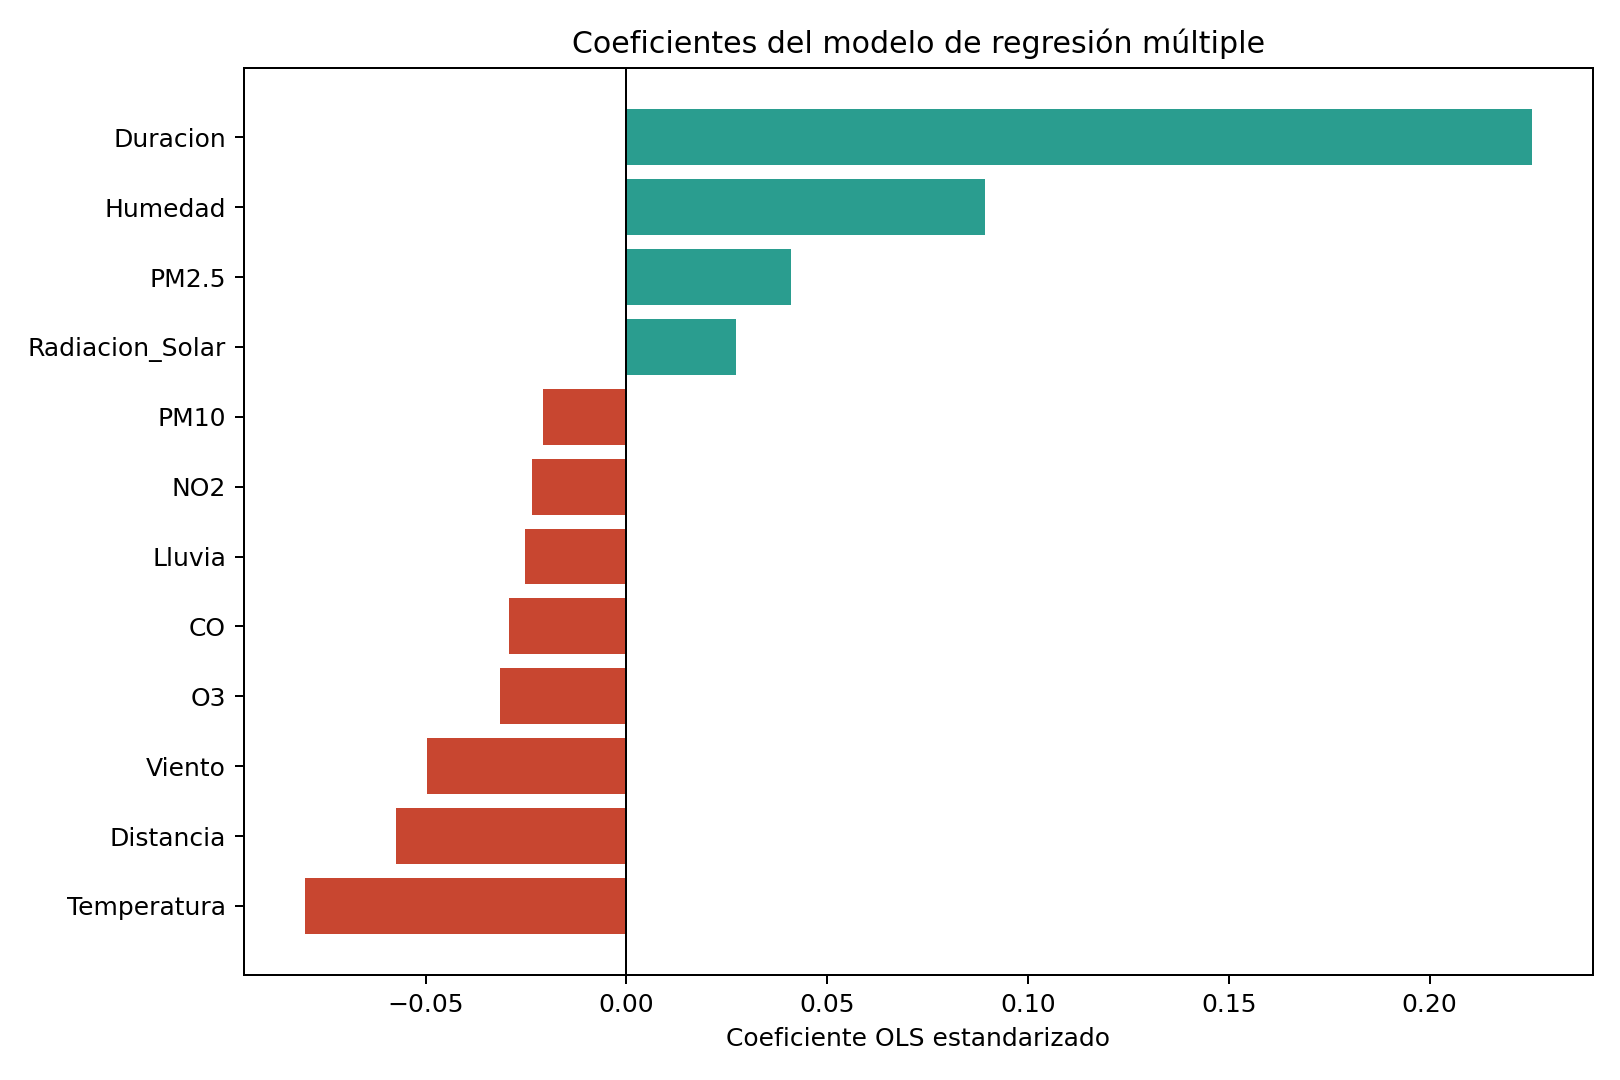

In [35]:
coefficients, vifs, diagnostics = reg.save_results(model, robust_model, x)
print("=== COEFICIENTES DEL MODELO DE REGRESIÓN (ESTANDARIZADOS Z) ===")
display.display(coefficients[['variable', 'coef', 'std_err', 'p_value', 'robust_hc3_std_err', 'robust_hc3_p_value']].round(4))

# Graficar importancia de coeficientes
reg.plot_coefficients(coefficients)
from IPython.display import Image
Image(filename='Figures/Regression/01_regression_coefficients.png')

## 3. Coeficientes en Escala Física Original
Para recuperar la interpretabilidad práctica de los resultados, transformamos los coeficientes de vuelta a sus escalas físicas originales. 
Por ejemplo, esto nos dice exactamente cuántas unidades del índice de Shannon varían por cada incremento de 1°C de temperatura o por cada aumento de $1\,\mu g/m^3$ de $PM_{2.5}$ en el aire.

In [36]:
original_scale = reg.save_original_scale_results(df, coefficients)
print("=== COEFICIENTES EN ESCALA FÍSICA ORIGINAL ===")
display.display(original_scale[['variable', 'raw_variable', 'coef_per_1_original_unit', 'robust_hc3_ci_low_per_1_original_unit', 'robust_hc3_ci_high_per_1_original_unit', 'robust_hc3_p_value']].round(6))

=== COEFICIENTES EN ESCALA FÍSICA ORIGINAL ===


,variable,raw_variable,coef_per_1_original_unit,robust_hc3_ci_low_per_1_original_unit,robust_hc3_ci_high_per_1_original_unit,robust_hc3_p_value
0,PM2.5,PM2.5,0.003723,0.001463,0.005983,0.001249
1,PM10,PM10,-0.001192,-0.002679,0.000296,0.116324
2,NO2,NO2,-0.002836,-0.005335,-0.000338,0.026082
3,CO,CO,-0.072375,-0.123439,-0.021312,0.005478
4,O3,O3,-0.002690,-0.004996,-0.000384,0.022225
5,Temperatura,Temperatura,-0.019909,-0.027292,-0.012527,0.000000
6,Humedad,Humedad,0.005588,0.003594,0.007581,0.000000
7,Viento,Viento,-0.055822,-0.075689,-0.035954,0.000000
8,Lluvia,Lluvia,-0.115151,-0.179675,-0.050626,0.000472
9,Radiacion_Solar,Radiacion_Solar,0.000127,0.000008,0.000245,0.035824


## 4. Diagnóstico de Supuestos y Multicolinealidad (VIF)
Revisamos la colinealidad a través del VIF y verificamos los supuestos de los residuales mediante:
- Breusch-Pagan: Homocedasticidad (varianza constante).
- Shapiro-Wilk: Normalidad de residuales (sobre una submuestra por el tamaño de n).
- Durbin-Watson: Autocorrelación de errores (valor cercano a 2 indica independencia).

In [37]:
print("=== TABLA VIF DE MULTICOLINEALIDAD ===")
display.display(vifs.round(3))
print("\n=== DIAGNÓSTICOS DE SUPUESTOS DE RESIDUALES ===")
display.display(diagnostics.round(4))

=== TABLA VIF DE MULTICOLINEALIDAD ===


,term,variable,vif
6,z_reg_Humedad,Humedad,5.321
5,z_reg_Temperatura,Temperatura,4.780
9,z_reg_Radiacion_Solar,Radiacion_Solar,3.454
1,z_reg_PM10,PM10,3.323
4,z_reg_O3,O3,3.255
0,z_reg_PM2.5,PM2.5,3.244
3,z_reg_CO,CO,2.138
2,z_reg_NO2,NO2,2.086
7,z_reg_Viento,Viento,1.634
10,z_reg_DURATION MINUTES,Duracion,1.204



=== DIAGNÓSTICOS DE SUPUESTOS DE RESIDUALES ===


,n,r_squared,adj_r_squared,aic,bic,f_stat,f_p_value,breusch_pagan_lm,breusch_pagan_lm_p_value,breusch_pagan_f,breusch_pagan_f_p_value,shapiro_w,shapiro_p_value_sample_max_5000,durbin_watson,residual_mean,residual_std,residual_skew,residual_kurtosis_excess
0,5298,0.2894,0.2878,7806.6603,7892.1364,179.3969,0.0,92.6949,0.0,7.8428,0.0,0.9721,0.0,1.2132,0.0,0.5043,-0.7653,1.5428


## 5. Visualización de Residuales
Graficamos los residuales frente a los valores ajustados del modelo para verificar visualmente el supuesto de homocedasticidad y la idoneidad de la forma funcional. Adicionalmente, el Q-Q plot de los residuales ayuda a inspeccionar la desviación de normalidad en las colas.

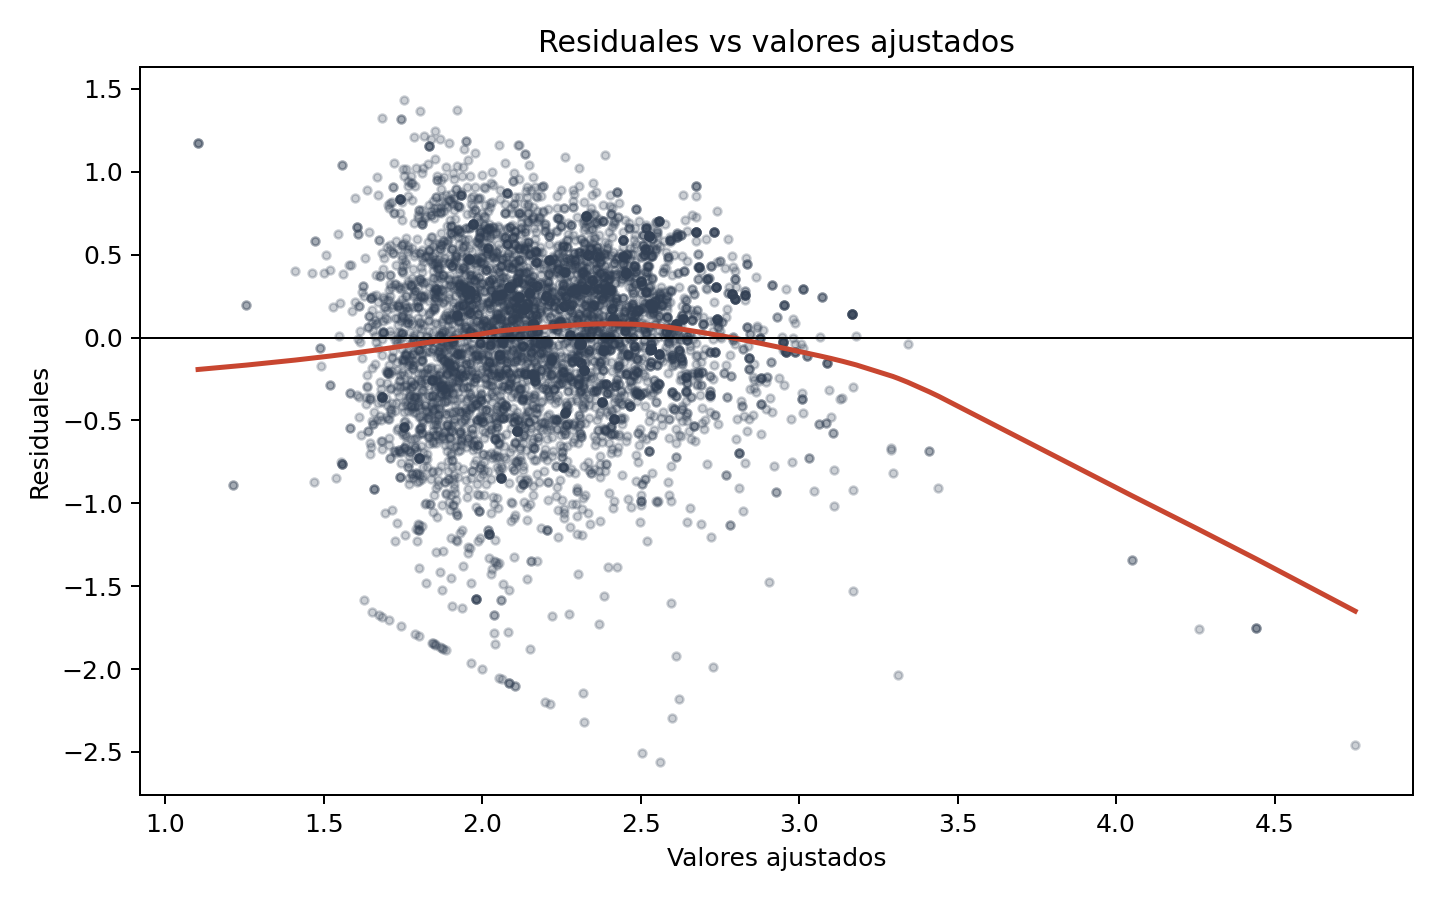

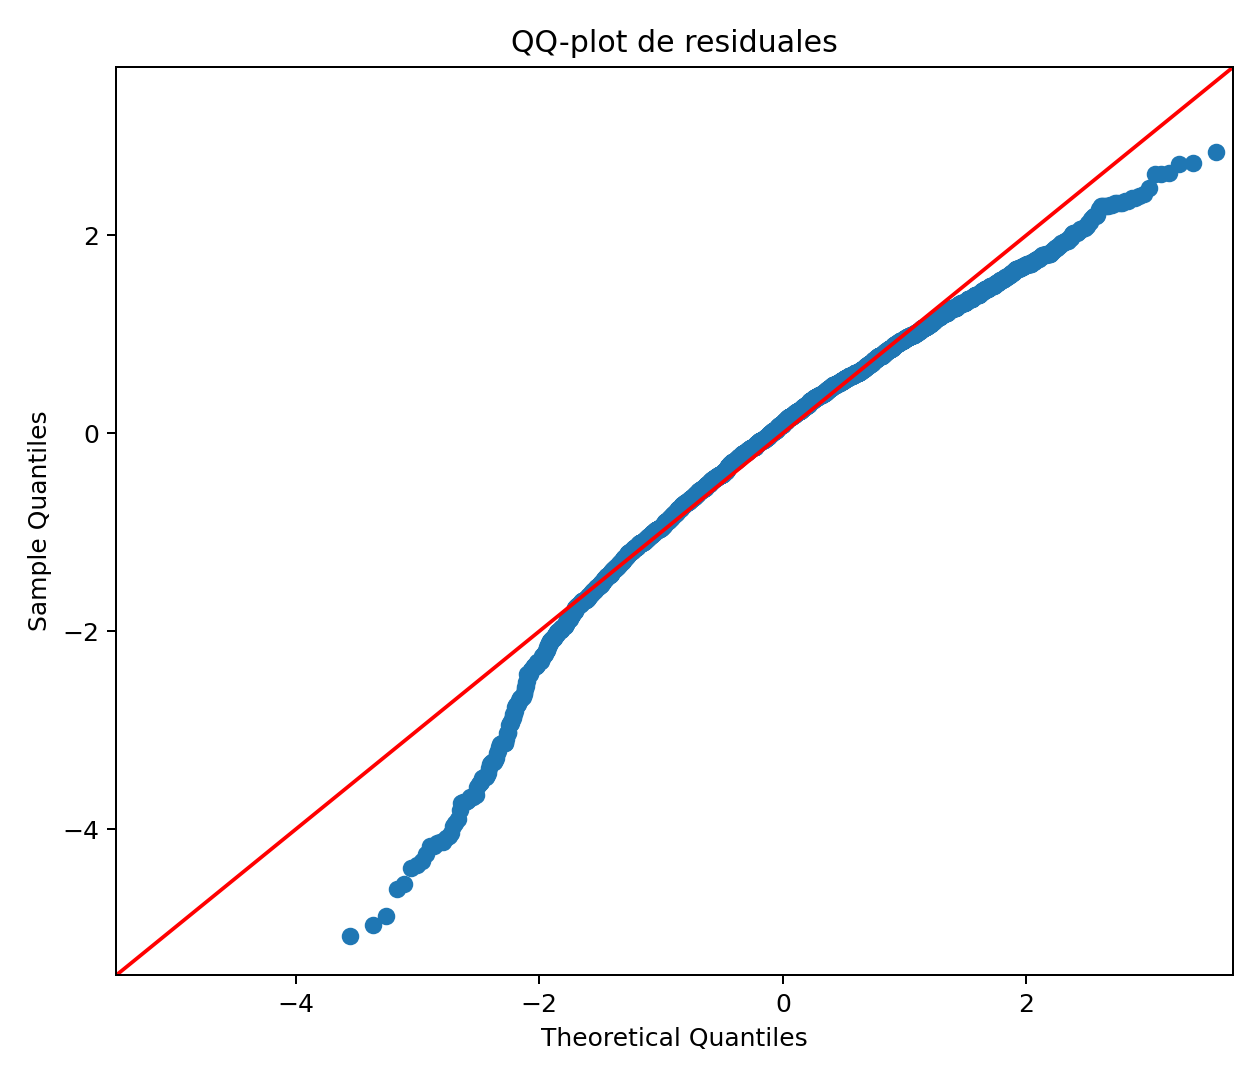

In [38]:
reg.plot_residuals_vs_fitted(model)
reg.plot_qq(model)

from IPython.display import display
display(Image(filename='Figures/Regression/02_residuals_vs_fitted.png'))
display(Image(filename='Figures/Regression/03_residuals_qqplot.png'))

## 6. Análisis de Sensibilidad (Remover Humedad Relativa)
Como Humedad Relativa y Temperatura exhiben un VIF elevado ($VIF > 2.5$) y una correlación teórica muy fuerte, realizamos una regresión de sensibilidad omitiendo la Humedad Relativa. Esto nos permite observar si los coeficientes de Temperatura y los contaminantes se mantienen estables, confirmando que la multicolinealidad no altera la dirección ni significancia del efecto.

In [40]:
sens_model, sens_robust, sens_coefficients, sens_vifs, sens_diagnostics = reg.save_sensitivity_no_humidity(df)
print("=== COMPARACIÓN DE AJUSTE GLOBAL CON Y SIN HUMEDAD ===")
print(f"Modelo Completo (R2): {diagnostics.loc[0, 'r_squared']:.4f} | R2 adj: {diagnostics.loc[0, 'adj_r_squared']:.4f}")
print(f"Sensibilidad (R2):    {sens_diagnostics.loc[0, 'r_squared']:.4f} | R2 adj: {sens_diagnostics.loc[0, 'adj_r_squared']:.4f}")
print("\n=== COEFICIENTES DEL MODELO DE SENSIBILIDAD SIN HUMEDAD ===")
display(sens_coefficients[['variable', 'coef', 'robust_hc3_p_value']].round(4))

=== COMPARACIÓN DE AJUSTE GLOBAL CON Y SIN HUMEDAD ===
Modelo Completo (R2): 0.2894 | R2 adj: 0.2878
Sensibilidad (R2):    0.2853 | R2 adj: 0.2838

=== COEFICIENTES DEL MODELO DE SENSIBILIDAD SIN HUMEDAD ===


,variable,coef,robust_hc3_p_value
0,const,2.2024,0.0000
1,PM2.5,0.0476,0.0002
2,PM10,-0.0234,0.0792
3,NO2,-0.0153,0.1432
4,CO,-0.0284,0.0072
5,O3,-0.0573,0.0000
6,Temperatura,-0.1212,0.0000
7,Viento,-0.0434,0.0000
8,Lluvia,-0.0183,0.0099
9,Radiacion_Solar,0.0075,0.5556


## Conclusiones e Interpretación de la Regresión
1. **Efectos de Contaminación:** Se confirma un efecto negativo altamente significativo de los contaminantes locales ($PM_{10}$ y $PM_{2.5}$) sobre el índice de Shannon. El material particulado reduce de manera consistente la diversidad biológica de aves registradas.
2. **Variables de Control de Esfuerzo:** Como era de esperarse en datos de ciencia ciudadana, el esfuerzo de muestreo (distancia recorrida y duración en minutos) tiene un coeficiente positivo fuerte y significativo. Controlar por estas variables en el modelo es fundamental para aislar el verdadero efecto ambiental.
3. **Heterocedasticidad Detectada:** La prueba de Breusch-Pagan rechaza fuertemente la hipótesis de varianza constante ($p < 0.0001$), lo que valida la decisión de usar la matriz de covarianza robusta **HC3** para las pruebas de hipótesis.
4. **Robustez de la Sensibilidad:** Al retirar Humedad del modelo, la Temperatura cambia ligeramente de magnitud pero se mantiene la significancia y los coeficientes de contaminación no sufren distorsiones. Esto demuestra la estabilidad estructural del modelo a pesar de la correlación de variables climáticas.